In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv('gurgaon_properties_outliers_done')

In [4]:
df.shapef

(3674, 24)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,price_area_ratio
0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,2.0,NaN,New Property,1081.0,NaN,650.0,0,0,0,0,0,0,8,360.333333
1,flat,smart world gems,sector 89,0.95,8597.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,4.0,NaN,New Property,NaN,NaN,1103.0,1,1,0,0,0,0,38,552.500000
2,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,17.0,NaN,New Property,NaN,1000.0,585.0,0,0,0,0,0,0,49,292.500000
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0,1,0,0,1,1,174,665.000000
4,flat,suncity avenue,sector 102,0.48,9023.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2,2,1,5.0,North-East,Relatively New,632.0,NaN,532.0,0,0,1,0,0,0,159,266.000000


In [181]:
df.isna().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1070
agePossession             0
super_built_up_area    1759
built_up_area          2050
carpet_area            1765
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
price_area_ratio          0
dtype: int64

**BUILT UP AREA**

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

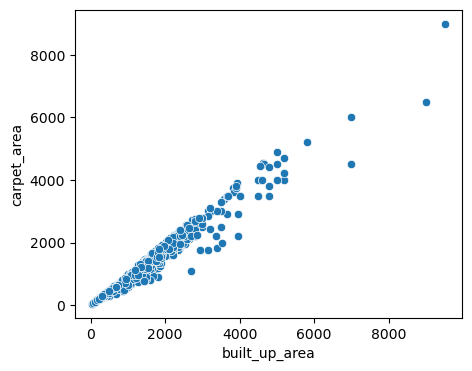

In [182]:
plt.figure(figsize=(5,4))
sns.scatterplot(x = df['built_up_area'],y=df['carpet_area'])

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

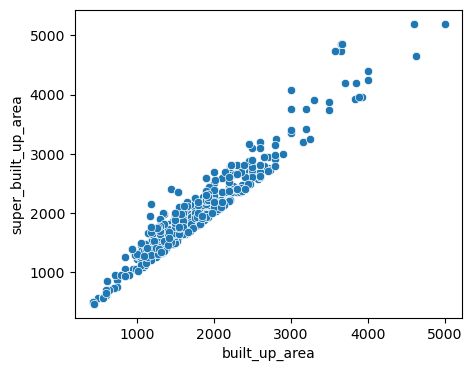

In [183]:
plt.figure(figsize=(5,4))
sns.scatterplot(x = df['built_up_area'],y=df['super_built_up_area'])

In [184]:
df[(df['built_up_area'].isna()) & (df['super_built_up_area'].isna()) & (df['carpet_area'].isna())].shape[0]

0

In [185]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [186]:
all_present_df.shape

(534, 24)

In [187]:
super_built_up_area_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [188]:
carpet_built_up_area_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [189]:
print(super_built_up_area_ratio,carpet_built_up_area_ratio)

1.1048701298701298 0.900140056022409


In [190]:
sbc_df = df[((~(df['super_built_up_area'].isna())) & (~(df['carpet_area'].isna())) & (df['built_up_area'].isna()))]

In [191]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2), inplace=True)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_3752/3548745466.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2), inplace=True)
/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_3752/3548745466.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

In [192]:
df.update(sbc_df)

In [193]:
df.isna().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1070
agePossession             0
super_built_up_area    1759
built_up_area          1622
carpet_area            1765
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
price_area_ratio          0
dtype: int64

In [194]:
sb_area = df[((~(df['super_built_up_area'].isna())) & (df['carpet_area'].isna()) & (df['built_up_area'].isna()))]

In [195]:
sb_area.shape

(903, 24)

In [196]:
sb_area['built_up_area'].fillna(round(df['super_built_up_area']/1.105),inplace=True)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_3752/1099773389.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_area['built_up_area'].fillna(round(df['super_built_up_area']/1.105),inplace=True)
/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_3752/1099773389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_are

In [197]:
df.update(sb_area)

In [198]:
df.isna().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1070
agePossession             0
super_built_up_area    1759
built_up_area           719
carpet_area            1765
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
price_area_ratio          0
dtype: int64

In [199]:
c_df = df[((df['super_built_up_area'].isna()) & (~(df['carpet_area'].isna())) & (df['built_up_area'].isna()))]

In [200]:
c_df.shape

(719, 24)

In [201]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.90),inplace=True)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_3752/3882625159.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.90),inplace=True)
/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_3752/3882625159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_a

In [202]:
df.update(c_df)

In [203]:
df['built_up_area'].isna().sum()

np.int64(0)

In [204]:
df[df['built_up_area']>20000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,price_area_ratio
1592,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,2,44,437500.00
2054,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Under Construction,NaN,20136.0,18122.0,1,0,0,1,1,1,44,4532.25


In [205]:
df.drop([1592],inplace=True)

In [206]:
df.drop([2054],inplace=True)

<Axes: xlabel='built_up_area', ylabel='price'>

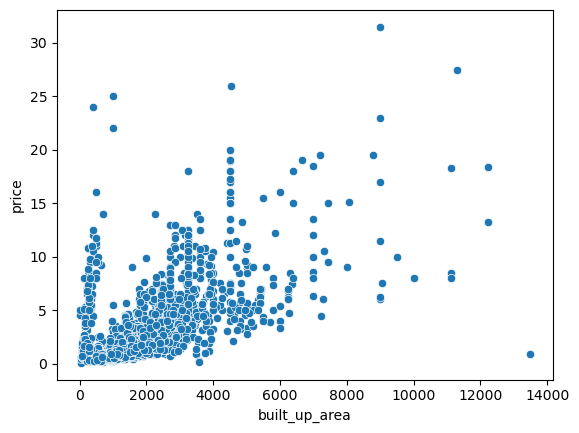

In [207]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [208]:
anamoly_df = df[(df['built_up_area']<2000) & (df['price']>2.5)][['price','area','built_up_area']]

In [209]:
anamoly_df.sample(5)

,price,area,built_up_area
2679,3.5,1975.0,1787.0
3422,2.9,2047.0,1852.0
2915,5.0,215517.0,2.0
1781,2.9,2003.0,1813.0
2135,2.6,1650.0,1833.0


In [210]:
anamoly_df['built_up_area'] = df['area']

In [211]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

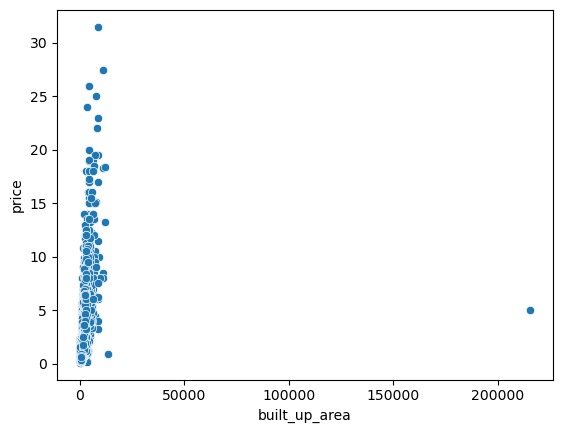

In [212]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [213]:
df[df['built_up_area']>20000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,price_area_ratio
2915,house,independent,sector 50,5.0,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,215517.0,NaN,1,1,0,1,1,1,0,35919.5


In [214]:
df.drop([2915],inplace=True)

<Axes: xlabel='built_up_area', ylabel='price'>

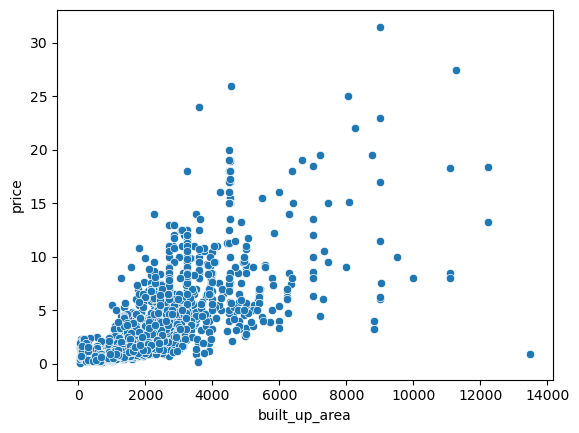

In [215]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [216]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','price_area_ratio'],inplace=True)

In [217]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1068
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

**FLOORNUM**

In [218]:
df[df['floorNum'].isna()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
500,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,0,0
774,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,0,9
1306,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,0,0
1478,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,0,21
1491,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,0,0
1985,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,0,0
2086,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,0,88
2199,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,0,0
2317,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,1,114
2494,house,dlf new town heights,sector 86,2.47,7719.0,4,4,3+,NaN,West,Moderately Old,2800.0,0,1,0,1,0,1,130


In [219]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [220]:
df['floorNum'].fillna(2.0,inplace=True)

/var/folders/77/wyg5lhbd4cb16lv4yrxznbf00000gn/T/ipykernel_3752/15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [221]:
df.drop(columns=['facing'],inplace=True)

In [222]:
df[df['society'].isna()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2598,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,0,0


In [223]:
df.drop([2598],inplace=True)

In [224]:
df.isna().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

**AgePossession**

In [225]:
df['agePossession'].value_counts()

agePossession
Relatively New        1633
New Property           589
Moderately Old         556
Undefined              317
Old Property           296
Under Construction     279
Name: count, dtype: int64

In [226]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
10,house,independent,sector 109,1.55,6568.0,3,2,0,1.0,Undefined,2360.0,0,0,0,0,0,0,0
33,house,greenopolis,sector 89,0.70,5397.0,2,2,2,14.0,Undefined,1297.0,0,0,0,0,0,0,0
47,flat,smart world gems,sector 89,1.71,12000.0,3,2,0,3.0,Undefined,1423.0,0,0,0,0,0,0,45
70,flat,rof aalayas,sector 102,0.45,6000.0,1,1,2,6.0,Undefined,750.0,0,0,0,0,0,0,0
74,house,bhim garh kheri,sector 3,1.50,7576.0,7,2,0,1.0,Undefined,1980.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3617,flat,signature global city,sector 37d,1.10,9839.0,2,2,2,4.0,Undefined,1242.0,0,0,0,0,0,0,59
3623,house,independent,sector 21,0.45,8411.0,3,2,1,1.0,Undefined,594.0,0,0,0,0,0,0,0
3626,flat,sare petioles,sector 92,1.30,6373.0,4,4,0,7.0,Undefined,2040.0,0,0,0,0,0,0,0
3637,flat,sidhartha ncr one,sector 95,0.57,4179.0,2,2,2,10.0,Undefined,1364.0,0,0,0,0,0,0,0


In [227]:
def mode_value_ap (row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [228]:
df['agePossession'] = df.apply(mode_value_ap,axis=1)

In [229]:
df['agePossession'].isna().sum()

np.int64(0)

In [231]:
df['agePossession'].value_counts()

agePossession
Relatively New        1752
New Property           636
Moderately Old         600
Old Property           328
Under Construction     296
Undefined               58
Name: count, dtype: int64

In [235]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [236]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [237]:
df['agePossession'].value_counts()

agePossession
Relatively New        1767
New Property           637
Moderately Old         607
Old Property           334
Under Construction     296
Undefined               29
Name: count, dtype: int64

In [238]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [239]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [240]:
df['agePossession'].value_counts()

agePossession
Relatively New        1769
New Property           637
Moderately Old         634
Old Property           334
Under Construction     296
Name: count, dtype: int64

In [241]:
df.isna().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [242]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)